Data Exploration Assigment:

For this data exploration assignemnt, we are looking at several different csv files on positive covid patients and trying to come up with unique observations. To start with, I will load in the files and take a look at the data. 

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#read in all csv files 
blood_pressure_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\blood_pressure.csv')
heart_rate_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\heart_rate.csv')
hrv_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\hrv_measurements.csv')
participants_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\participants.csv')
scales_description_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\scales_description.csv')
sleep_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\sleep.csv')
survey_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\surveys.csv')
wearables_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\wearables.csv')
weather_csv = pd.read_csv(r'C:\GitRepos\XGboost_model_dev_Rodin\aipi510-fall25\data\weather.csv')


Now that I have loaded in all the CSV files succesfully, I will begin an exploratory analysis - looking at features, data quality etc for several of the datasets before exploring one or two more in depth. 

In [4]:
#looking at blood pressure CSV 
blood_pressure_csv.head()
blood_pressure_csv.info()
blood_pressure_csv.describe()
blood_pressure_csv.isnull().sum()

#lots of null values in circulatory_efficiency, gerdo_vegetation_index, robinson_index

#mean diastolic blood pressure 
mean_diastolic = blood_pressure_csv['diastolic'].mean()
print(f'Mean Diastolic Blood Pressure: {mean_diastolic}')

#mean systolic blood pressure 
mean_systolic = blood_pressure_csv['systolic'].mean()
print(f'Mean Systolic Blood Pressure: {mean_systolic}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_code                 721 non-null    object 
 1   measurement_datetime      721 non-null    object 
 2   diastolic                 721 non-null    int64  
 3   systolic                  721 non-null    int64  
 4   functional_changes_index  299 non-null    float64
 5   circulatory_efficiency    299 non-null    float64
 6   kerdo_vegetation_index    283 non-null    float64
 7   robinson_index            299 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 45.2+ KB
Mean Diastolic Blood Pressure: 81.22884882108183
Mean Systolic Blood Pressure: 119.44105409153953


After exploring the blood pressure csv dataset ever so briefly, I found that the mean diastolic blood pressure for positive covid patients is 81.22 while the mean systolic blood preassure is 119.44. For healthy people, the averages are right around 80 and 120 respecitvely, with less than 80 and 120 being considered normal. So, the diatolic blood pressure on average might be a tiny bit higher than the populations but not drastically. We would have to do a full statistical analysis to see if this is significant or not. 

In [5]:
#hr measurements
heart_rate_csv.head()
heart_rate_csv.info()
heart_rate_csv.describe()
heart_rate_csv.isnull().sum()

mean_hr = heart_rate_csv['heart_rate'].mean()
print(f'Mean Heart Rate: {mean_hr}')

#hrv measurements
hrv_csv.head()
hrv_csv.info()
hrv_csv.describe()
hrv_csv.isnull().sum()
mean_hrv = hrv_csv['bpm'].mean()
print(f'Mean bpm: {mean_hrv}')

#sleep measurements 
sleep_csv.head()
sleep_csv.info()
sleep_csv.describe()
sleep_csv.isnull().sum()
mean_sleep = sleep_csv['sleep_duration'].mean()
print(f'Mean Sleep Duration: {mean_sleep}')
sleep_hours = mean_sleep / 3600
print(f'Mean Sleep Duration in Hours: {sleep_hours}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523783 entries, 0 to 523782
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_code   523783 non-null  object
 1   datetime    523783 non-null  object
 2   heart_rate  523783 non-null  int64 
 3   is_resting  523783 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 16.0+ MB
Mean Heart Rate: 90.85662574004884
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   object 
 1   rr_code               3245 non-null   object 
 2   measurement_datetime  3245 non-null   object 
 3   time_of_day           3245 non-null   object 
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   


## Data Handling: Missing Values, Duplicates, Outliers

We handle missing values, duplicates, and identify outliers.  
We'll compute mean, median, min, max, and quartiles (25%, 75%) for key columns in the sleep and heart rate datasets. 



In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Heart Rate dataset ---
print("Heart Rate dataset — Missing values per column:")
print(heart_rate_csv.isna().sum())

heart_rate_csv = heart_rate_csv.drop_duplicates()

desc_hr = heart_rate_csv.describe(percentiles=[0.25, 0.5, 0.75]).T
display(desc_hr[['mean','50%','min','25%','75%','max']])

# --- Sleep dataset ---
print("\nSleep dataset — Missing values per column:")
print(sleep_csv.isna().sum())

sleep_csv = sleep_csv.drop_duplicates()

desc_sleep = sleep_csv.describe(percentiles=[0.25, 0.5, 0.75]).T
display(desc_sleep[['mean','50%','min','25%','75%','max']])


Heart Rate dataset — Missing values per column:
user_code     0
datetime      0
heart_rate    0
is_resting    0
dtype: int64


,mean,50%,min,25%,75%,max
heart_rate,90.856626,87.0,10.0,71.0,108.0,232.0
is_resting,0.005546,0.0,0.0,0.0,0.0,1.0



Sleep dataset — Missing values per column:
user_code                 0
day                       0
sleep_begin               0
sleep_end                 0
sleep_duration            0
sleep_awake_duration    416
sleep_rem_duration      418
sleep_light_duration    398
sleep_deep_duration     411
pulse_min               410
pulse_max               410
pulse_average           410
dtype: int64


,mean,50%,min,25%,75%,max
sleep_duration,25699.731765,26041.000,930.000,21857.000,30600.00,47460.0
sleep_awake_duration,2733.333333,2490.000,1740.000,2460.000,2790.00,4200.0
sleep_rem_duration,6518.571429,6240.000,2820.000,5730.000,8190.00,8730.0
sleep_light_duration,14514.740741,17340.000,300.000,7995.000,20340.00,23100.0
sleep_deep_duration,4280.285714,4230.000,480.000,2797.500,5550.00,7934.0
pulse_min,60.533333,58.000,52.000,54.500,60.00,105.0
pulse_max,89.866667,93.000,62.000,85.000,94.50,105.0
pulse_average,68.880733,65.857,59.444,63.393,70.25,105.0


From this analysis, we see that there are several outliers, such as 47,460 seconds or 13.18 hours of sleep in a day, which is likely an error. The mean sleep duration is 6.5 hours, which seems reasonable. We also see that there are some missing values in the sleep duration column, which we will need to handle appropriately in our analysis. 

Furthermore, we see that in the heart rate analysis the minimum is 10.0 which almost certainly an artifact and can be determined as an outlier. The next step is getting rid of null values and these outliers. 

<class 'pandas.core.frame.DataFrame'>
Index: 523612 entries, 0 to 523782
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_code   523612 non-null  object
 1   datetime    523612 non-null  object
 2   heart_rate  523612 non-null  int64 
 3   is_resting  523612 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 20.0+ MB


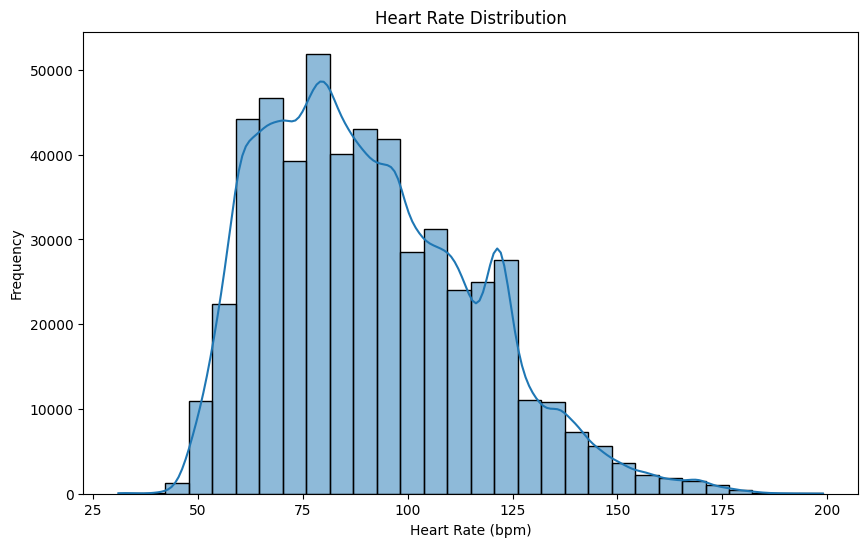

In [7]:
#get rid of rows where heart rate is NA 

heart_rate_csv = heart_rate_csv.dropna(subset=['heart_rate'])
heart_rate_csv = heart_rate_csv[heart_rate_csv['heart_rate'] > 30]  # Filter out heart rates <= 30
heart_rate_csv = heart_rate_csv[heart_rate_csv['heart_rate'] < 200]  # Filter out heart rates >= 200
heart_rate_csv.info()
#plot heart rate distribution
plt.figure(figsize=(10,6))
sns.histplot(heart_rate_csv['heart_rate'], bins=30, kde=True)
plt.title('Heart Rate Distribution')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.show()




Now that we have removed the outliers and null values, we can see that this plot of heart rate values is much more normally distributed. We will now do the same thing with sleep duration and then move on to further analysis. 

<class 'pandas.core.frame.DataFrame'>
Index: 416 entries, 1 to 424
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             416 non-null    object 
 1   day                   416 non-null    object 
 2   sleep_begin           416 non-null    object 
 3   sleep_end             416 non-null    object 
 4   sleep_duration        416 non-null    float64
 5   sleep_awake_duration  9 non-null      float64
 6   sleep_rem_duration    7 non-null      float64
 7   sleep_light_duration  27 non-null     float64
 8   sleep_deep_duration   14 non-null     float64
 9   pulse_min             15 non-null     float64
 10  pulse_max             15 non-null     float64
 11  pulse_average         15 non-null     float64
dtypes: float64(8), object(4)
memory usage: 42.2+ KB


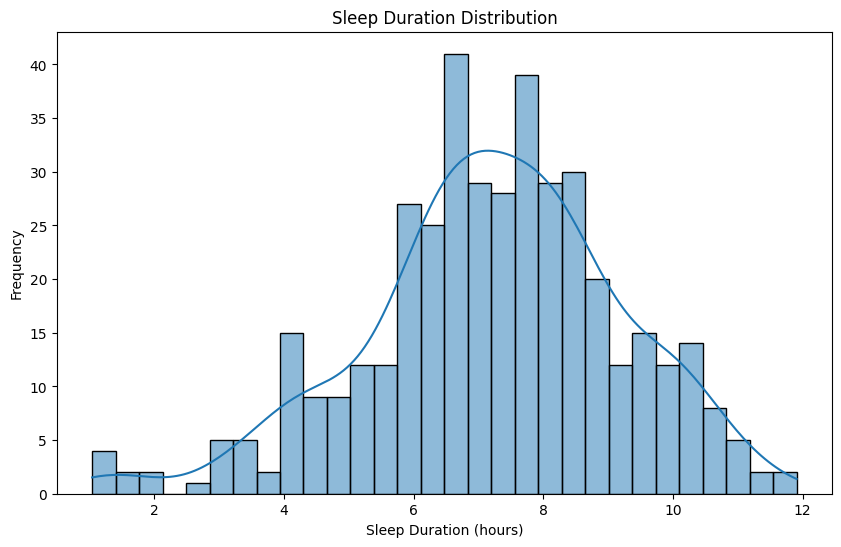

In [8]:
#same thing with sleep 
sleep_csv = sleep_csv.dropna(subset=['sleep_duration'])
sleep_csv = sleep_csv[sleep_csv['sleep_duration'] > 3600]  # Filter out sleep durations <= 1 hour
sleep_csv = sleep_csv[sleep_csv['sleep_duration'] < 43200]  # Filter out sleep durations >= 12 hours
sleep_csv.info()    
#plot sleep duration distribution
plt.figure(figsize=(10,6))
sns.histplot(sleep_csv['sleep_duration']/3600, bins=30, kde=True)  # Convert seconds to hours for better interpretability
plt.title('Sleep Duration Distribution')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Frequency')
plt.show()



## Heart Rate & Sleep Analysis by User

We group by `user_id` (or equivalent ID column), compute average HR and sleep, and compare distributions.  
Since no 'healthy' group exists, we compare against **external reference values** (e.g., resting HR ~ 60–100 bpm; recommended sleep ~ 7–9 hours).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime parsing
heart_rate_csv['datetime'] = pd.to_datetime(heart_rate_csv['datetime'], errors='coerce')
sleep_csv['sleep_begin'] = pd.to_datetime(sleep_csv['sleep_begin'], errors='coerce')
sleep_csv['sleep_end'] = pd.to_datetime(sleep_csv['sleep_end'], errors='coerce')

# Convert sleep_duration to hours
sleep_csv['sleep_hours'] = sleep_csv['sleep_duration'] / 3600.0

# Container for per-night HR summaries
records = []

for _, row in sleep_csv.iterrows():
    uid = row['user_code']
    start, end = row['sleep_begin'], row['sleep_end']
    
    # Subset HR data for this user & interval
    hr_sub = heart_rate_csv[
        (heart_rate_csv['user_code'] == uid) &
        (heart_rate_csv['datetime'] >= start) &
        (heart_rate_csv['datetime'] <= end)
    ]
    
    if len(hr_sub) > 0:
        records.append({
            'user_code': uid,
            'date': start.date(),
            'sleep_hours': row['sleep_hours'],
            'sleep_begin': start,
            'sleep_end': end,
            'mean_hr_sleep': hr_sub['heart_rate'].mean(),
            'min_hr_sleep': hr_sub['heart_rate'].min(),
            'max_hr_sleep': hr_sub['heart_rate'].max(),
            'n_hr_points': len(hr_sub)
        })

# Build nightly summary dataframe
nightly_summary = pd.DataFrame(records)
display(nightly_summary.head())

# --- Plot 1: Scatter of sleep duration vs mean HR during sleep ---
plt.figure(figsize=(6,4))
plt.scatter(nightly_summary['sleep_hours'], nightly_summary['mean_hr_sleep'], alpha=0.6)
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Mean HR during sleep (bpm)")
plt.title("Relationship between Sleep Duration and Mean Sleeping HR")
plt.show()

# --- Plot 2: Histogram of mean HR during sleep ---
plt.figure(figsize=(6,4))
nightly_summary['mean_hr_sleep'].hist(bins=30, alpha=0.7)
plt.axvline(55, linestyle='--', label='Healthy lower (55 bpm)')
plt.axvline(90, linestyle='--', label='Healthy upper (90 bpm)')
plt.legend()
plt.title("Distribution of Mean Sleeping HR")
plt.xlabel("HR (bpm)")
plt.ylabel("Count")
plt.show()


We see from this analysis that there is very little relationship between sleep duration and mean sleeping hr. Also, the distribtution of mean sleeping hr is very tightly clustered around 60-80 bpm, which is a normal resting heart rate. The sleep duration is more spread out, but most people are getting between 5-8 hours of sleep, which is within the recommended range. It does seem though, just from a glance that if you get very little sleep your mean sleeping heart rate seems to be slightly higher. 

Since this was not a super interesting result, I decided to continue looking at the data - exploring the survey information with HRV data. 

Merged rows: 149


,user_code,date,rmssd,sdnn,pnn50,hf,lf,S_COVID_BLUISH,S_COVID_BREATH,S_COVID_CONFUSION,S_COVID_COUGH,S_COVID_FATIGUE,S_COVID_FEVER,S_COVID_OVERALL,S_COVID_PAIN,S_COVID_TROUBLE,symptom_days,corona_like,symptom_severity_sum,symptom_severity_max
0,01bad5a519,2020-04-23,29.078000,29.3480,4.040000,103.000000,67.750000,0,2,0,1,0,0,1,2,2,NaN,NaN,8,2
1,01bad5a519,2020-04-25,23.976500,31.7890,4.545000,160.000000,188.000000,0,0,0,1,0,0,1,1,0,NaN,NaN,3,1
2,01bad5a519,2020-04-27,19.667333,33.9660,4.376667,141.666667,115.666667,0,1,0,1,0,0,0,1,1,NaN,NaN,4,1
3,01bad5a519,2020-04-29,23.688000,30.9865,4.797500,87.000000,400.000000,0,0,0,1,0,0,3,1,1,NaN,NaN,6,3
4,01bad5a519,2020-05-03,19.338800,21.7494,2.020000,53.600000,69.000000,0,0,0,0,1,0,4,1,0,NaN,NaN,6,4


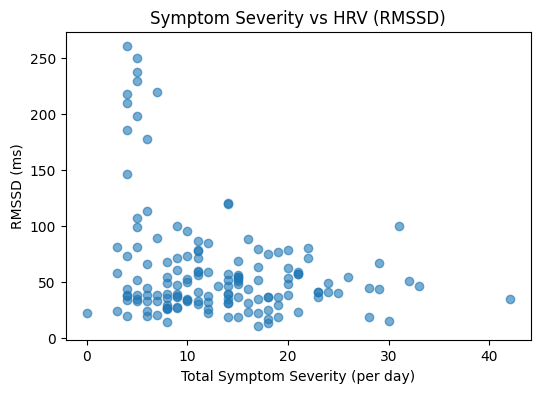

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parse datetime columns 
survey_csv['created_at'] = pd.to_datetime(survey_csv['created_at'], errors='coerce')
hrv_csv['measurement_datetime'] = pd.to_datetime(hrv_csv['measurement_datetime'], errors='coerce')

survey_csv['date'] = survey_csv['created_at'].dt.date
hrv_csv['date'] = hrv_csv['measurement_datetime'].dt.date

#  Define mappings based on scales_description 
intensity_scales = [
    'S_COVID_COUGH','S_COVID_FEVER','S_COVID_BREATH','S_COVID_FATIGUE',
    'S_COVID_PAIN','S_COVID_CONFUSION','S_COVID_TROUBLE','S_COVID_BLUISH',
    'S_COVID_OVERALL'
]

def intensity_severity(val):
    return np.clip((val - 1), 0, 5)  # 1 → 0 (none), 6 → 5 (extremely severe)

duration_map = {1: 2.0, 2: 4.5, 3: 10.5, 4: 16.0}  # midpoints in days
corona_like_map = {2: 4, 1: 3, 3: 2, 4: 1, 5: 0}

#  Build symptom features 
covid = survey_csv[survey_csv['scale'].str.startswith('S_COVID', na=False)].copy()

# Intensity symptoms
intensity_df = (
    covid[covid['scale'].isin(intensity_scales)]
    .assign(severity=lambda d: intensity_severity(d['value']))
    .pivot_table(index=['user_code','date'], columns='scale', values='severity', aggfunc='max')
    .reset_index()
)

# Symptom duration
duration_df = (
    covid[covid['scale'] == 'S_COVID_SYMPTOMS'][['user_code','date','value']]
    .assign(symptom_days=lambda d: d['value'].map(duration_map))
    .groupby(['user_code','date'], as_index=False)['symptom_days'].max()
)

# Corona likelihood
corona_df = (
    covid[covid['scale'] == 'S_CORONA'][['user_code','date','value']]
    .assign(corona_like=lambda d: d['value'].map(corona_like_map))
    .groupby(['user_code','date'], as_index=False)['corona_like'].max()
)

# Merge symptom features
symptom_features = intensity_df.merge(duration_df, on=['user_code','date'], how='outer') \
                               .merge(corona_df, on=['user_code','date'], how='outer')

# Add overall severity metrics
severity_cols = [c for c in symptom_features.columns if c.startswith('S_COVID_') and c not in ['S_COVID_SYMPTOMS']]
symptom_features['symptom_severity_sum'] = symptom_features[severity_cols].fillna(0).sum(axis=1)
symptom_features['symptom_severity_max'] = symptom_features[severity_cols].max(axis=1)

# --- Aggregate HRV daily ---
hrv_daily = (
    hrv_csv.groupby(['user_code','date'], as_index=False)[['rmssd','sdnn','pnn50','hf','lf']]
    .mean()
)

# Merge HRV with symptom features
merged = hrv_daily.merge(symptom_features, on=['user_code','date'], how='inner')

#  Quick check 
print("Merged rows:", merged.shape[0])
display(merged.head())

# Example plot: symptom severity vs RMSSD 
plt.figure(figsize=(6,4))
plt.scatter(merged['symptom_severity_sum'], merged['rmssd'], alpha=0.6)
plt.xlabel("Total Symptom Severity (per day)")
plt.ylabel("RMSSD (ms)")
plt.title("Symptom Severity vs HRV (RMSSD)")
plt.show()


This plot looks wrong lol didn't have time to finish!